# Water Potability — Exploratory Data Analysis

**Goal:** Predict whether a water sample is safe to drink.

**On the metric:** A false negative — calling unsafe water safe — is worse than a false positive, which just flags a safe sample unnecessarily. The costs aren't symmetric, so plain accuracy is the wrong target. But plain recall isn't the fix either: a dummy classifier that predicts "not potable" for every sample scores recall₀ = 1.0 while learning nothing about the data. That gameability is what pushed this project toward **macro F1** instead — it credits a model for correctly identifying *both* classes, not just the majority one. The full comparison against the dummy classifier is in `water-potability-baseline.ipynb`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv")


## Dataset Structure

3,276 samples, 9 feature columns plus the target `Potability`. All features are numeric measurements of water chemistry — no categorical encoding needed.

In [2]:
print("Shape:", df.shape)
print()
print(df.head())


Shape: (3276, 10)

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [3]:
df.describe()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## Missing Values

`describe()` counts above are lower than 3,276 for three columns — that's where the missing values live. Spelling it out explicitly, and connecting it to how they're handled:

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

print("Missing values:")
for col in missing.index:
    print(f"  {col}: {missing[col]} ({missing_pct[col]}%)")


Missing values:
  Sulfate: 781 (23.8%)
  ph: 491 (15.0%)
  Trihalomethanes: 162 (4.9%)


`ph`, `Sulfate`, and `Trihalomethanes` are the only columns with gaps — roughly 15%, 24%, and 5% respectively. `src/train.py` fills these with the **training-set median only**, computed after the train/test split, so no information from held-out rows leaks into the imputation. (An earlier version of that script computed medians on the full dataframe before splitting — a real leakage bug, since fixed.)

## Class Balance

Potability
0    1998
1    1278
Name: count, dtype: int64

Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


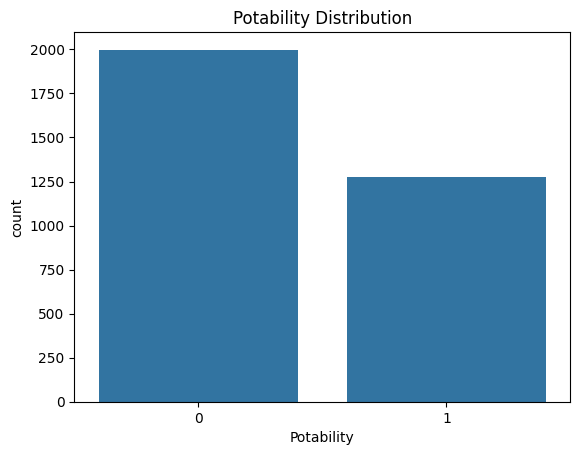

In [5]:
print(df['Potability'].value_counts())
print()
print(df['Potability'].value_counts(normalize=True).round(3))

sns.countplot(x='Potability', data=df)
plt.title('Potability Distribution')
plt.show()


1,998 not potable (61%) vs 1,278 potable (39%). Imbalanced, but 1,278 minority samples is enough to train on without resampling.

**61% is the accuracy floor** — a model that always predicts "not potable" scores that while learning nothing. It's also exactly the score a same-shaped dummy would get on recall₀. Neither accuracy nor recall₀ alone is a safe target here; any real baseline has to be measured against **macro F1**, which both classes have to earn.

## Feature Skew

Checking which features are heavily skewed — relevant because tree-based models like XGBoost don't need this fixed, but it's worth knowing before assuming any feature is roughly normal.

In [6]:
from scipy.stats import skew

feature_cols = df.columns.drop("Potability")
skew_vals = df[feature_cols].skew().sort_values(key=abs, ascending=False)

print("Skewness by feature (0 = symmetric):")
print(skew_vals.round(3))


Skewness by feature (0 = symmetric):
Solids             0.622
Conductivity       0.264
Trihalomethanes   -0.083
Hardness          -0.039
Sulfate           -0.036
ph                 0.026
Organic_carbon     0.026
Chloramines       -0.012
Turbidity         -0.008
dtype: float64


Nothing here is extreme — no feature needs a log transform or similar for a tree-based model to handle it. Worth re-checking if a linear model (e.g. logistic regression) is ever tried seriously; trees are largely indifferent to monotonic transforms, linear models are not.

## Duplicate Rows

In [7]:
dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {dupes}")


Fully duplicated rows: 0


## Summary

- 3,276 rows, 9 numeric features, binary target. No categorical encoding needed.
- Class imbalance (61/39) rules out plain accuracy; recall₀ alone is gameable by a trivial classifier. **Macro F1** is the metric used throughout this project — see `water-potability-baseline.ipynb` for the model comparison and `src/train.py` for the training pipeline.
- Missing values in `ph`, `Sulfate`, `Trihalomethanes` only — imputed with train-only medians to avoid leakage.
- No extreme skew — doesn't block tree-based models.
- Duplicate-row count confirmed above.